# Notebook 06 — Framework de Modelado por Checkpoints
Objetivo: Definir y construir los modelos predictivos para CP1 y CP2 con niveles de alerta derivados empíricamente. Dado el ajuste, tanto CP1 como CP2 predice solo APROBADO/REPROBADO (binario), sin incluir retiro en CP1 para evitar issues con datos de retirados.
Este notebook es el núcleo del sistema de alerta temprana. Incorpora como decisión central que los niveles de alerta no son definidos manualmente, sino derivados de las probabilidades empíricas calculadas sobre los datos históricos. Los modelos para CP1 y CP2 tienen targets binarios, features y estrategias de validación adaptadas.

Preparación del Entorno y Carga de Datos
En esta sección, cargamos el dataset y la Tabla Maestra de NB05. Definimos subconjuntos clave, usando solo activos para ambos checkpoints (binario).
Justificación: Basado en hallazgos de NB01-NB05, usamos df_activos_engagement para CP1 y CP2 (binario, excluyendo retirados).

In [5]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score, confusion_matrix,
    ConfusionMatrixDisplay, brier_score_loss, mean_absolute_error,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Cargar el dataset y Tabla Maestra de NB05
df_all = pd.read_csv('../data/dataset_completo_final.csv')
tabla_maestra = pd.read_csv('tabla_maestra_features.csv')

# Codificar era en df_all ANTES de filtrar subconjuntos
df_all['era_encoded'] = (df_all['era'] == 'formato_nuevo').astype(int)

# Subconjuntos clave (ahora incluyen era_encoded)
df_activos = df_all[df_all['estado'].isin(['APROBÓ', 'REPROBÓ'])].copy()  # N=554
df_activos_engagement = df_activos[df_activos['engagement_hasta_p1'] > 0].copy()  # N=502

# Chequeo de columnas para depurar (puedes remover después)
print("Columnas en df_all:\n", df_all.columns.tolist())
print("Columnas en df_activos:\n", df_activos.columns.tolist())
print("Ejemplo de era_encoded en df_activos:\n", df_activos['era_encoded'].head())

print(f"Dimensiones: df_all={df_all.shape}, df_activos={df_activos.shape}, df_activos_engagement={df_activos_engagement.shape}")

Columnas en df_all:
 ['semestre', 'era', 'id_estudiante', 'estado', 'nota_100', 'parcial_1', 'parcial_1_modo', 'parcial_2', 'parcial_2_modo', 'parcial_3', 'parcial_3_modo', 'fase_1', 'fase_1_modo', 'fase_2', 'fase_2_modo', 'taller_1', 'taller_1_modo', 'taller_2', 'taller_2_modo', 'taller_3', 'taller_3_modo', 'am_1', 'am_1_modo', 'am_2', 'am_2_modo', 'am_3', 'am_3_modo', 'am_4', 'am_4_modo', 'am_5', 'am_5_modo', 'am_6', 'am_6_modo', 'quiz_1', 'quiz_1_modo', 'quiz_2', 'quiz_2_modo', 'quiz_3', 'quiz_3_modo', 'quiz_4', 'quiz_4_modo', 'quiz_5', 'quiz_5_modo', 'quiz_6', 'quiz_6_modo', 'promedio_ams', 'promedio_quices', 'actividades_n_realizadas', 'actividades_tiempo_promedio', 'actividades_tiempo_total', 'actividades_visitas_total', 'engagement_hasta_p1', 'engagement_hasta_p2', 'engagement_hasta_p3', 'parcial_1_modulos_unicos', 'parcial_1_temas_unicos', 'parcial_1_tiempo_hrs', 'parcial_1_tiempo_por_visita', 'parcial_1_visitas', 'parcial_1_visitas_por_tema', 'parcial_2_modulos_unicos', 'parci

# Sección 6.1 — Definición de Targets por Checkpoint
Una decisión fundamental en el rediseño: ambos checkpoints tienen target binario que refleja las realidades operativas del semestre, sin incluir retiro en CP1.

📈  CP1 (Semana 6): Target Binario — REPROBARÁ / APROBARÁ. A la semana 6, el foco es predicción de reprobación con features tempranas.

📈  CP2 (Semana 11): Target Binario — REPROBARÁ / APROBARÁ. A la semana 11, los retiros ya ocurrieron. Solo quedan estudiantes activos.
Python

In [6]:
# Target binario para CP1 y CP2: 1=REPROBARÁ (REPROBÓ), 0=APROBARÁ (APROBÓ)
df_activos_engagement['target_binario'] = (df_activos_engagement['estado'] == 'REPROBÓ').astype(int)

print("Distribución target binario:\n", df_activos_engagement['target_binario'].value_counts(normalize=True))

Distribución target binario:
 target_binario
0    0.743028
1    0.256972
Name: proportion, dtype: float64


# Sección 6.2 — Derivación Empírica de Niveles de Alerta
Esta es la innovación central respecto al diseño original: los umbrales de riesgo no se definen manualmente sino que se derivan de las probabilidades condicionales empíricas calculadas en el dataset histórico.

## 6.2.1 Metodología de derivación de umbrales
El proceso toma como entrada las probabilidades de reprobación calculadas en NB02 (tabla de riesgo) y las extiende al espacio multivariado usando las probabilidades predichas por el modelo.
Pasos:

1. Calcular P(REPROBÓ | intervalo_P1) — ya disponibles del NB02.
2. Usar estas probabilidades como guía para definir umbrales en las probabilidades predichas del modelo.
3. Calibrar el modelo con Platt Scaling o Isotonic Regression para que las probabilidades predichas sean bien calibradas.
4. Mapear las probabilidades calibradas a los niveles de alerta usando cuantiles históricos.

In [7]:
# Intervalos de P1 del NB02
bins_p1 = [0, 1.5, 2.5, 3.0, 3.5, 4.0, np.inf]
labels_p1 = ['[0,1.5)', '[1.5,2.5)', '[2.5,3.0)', '[3.0,3.5)', '[3.5,4.0)', '[4.0+)']

# Calcular P(REPROBÓ | intervalo_P1) en df_activos
df_activos['intervalo_p1'] = pd.cut(df_activos['parcial_1'], bins=bins_p1, labels=labels_p1)
p_reprob_p1 = df_activos.groupby('intervalo_p1')['target_binario'].mean() if 'target_binario' in df_activos.columns else df_activos.groupby('intervalo_p1')['estado'].apply(lambda x: (x == 'REPROBÓ').mean())

# Tabla empírica (base para umbrales)
tabla_riesgo = pd.DataFrame({
    'Intervalo_P1': labels_p1,
    'P_REPROBO': p_reprob_p1.values
})
print(tabla_riesgo)

  Intervalo_P1  P_REPROBO
0      [0,1.5)   0.800000
1    [1.5,2.5)   0.572816
2    [2.5,3.0)   0.298077
3    [3.0,3.5)   0.147287
4    [3.5,4.0)   0.157303
5       [4.0+)   0.009259


C:\Users\nicot\AppData\Local\Temp\ipykernel_22864\1882874734.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p_reprob_p1 = df_activos.groupby('intervalo_p1')['target_binario'].mean() if 'target_binario' in df_activos.columns else df_activos.groupby('intervalo_p1')['estado'].apply(lambda x: (x == 'REPROBÓ').mean())


## 6.2.2 Tabla de niveles de alerta — CP1 (derivada empíricamente)
| Nivel | P(Riesgo) Predicha | Base Empírica (P1 Histórico) | Acción Sugerida | N Esperado (CP1) |
| :--- | :--- | :--- | :--- | :--- |
| **CRÍTICO** | $\ge 0.70$ | P1 < 1.5: 80% reprobó | Contacto inmediato tutor + coordinador | ~19 (3.5%) |
| **ALTO** | 0.50 – 0.69 | P1 1.5-2.5: 57% reprobó | Sesión de refuerzo + monitoreo semanal | ~102 (18%) |
| **MODERADO** | 0.25 – 0.49 | P1 2.5-3.0: 30% reprobó | Recomendación de recursos + revisión P1 | ~100 (18%) |
| **SEGUIMIENTO** | 0.10 – 0.24 | P1 3.0-3.5: 15% reprobó | Alerta preventiva, monitoreo P2 | ~128 (23%) |
| **SEGURO** | < 0.10 | P1 3.5-4.0: 16% / P1 $\ge$ 4.0: 1% | Sin intervención activa | ~205 (37%) |

## 6.2.3 Calibración del modelo y derivación automática de umbrales
El proceso de derivación automática de umbrales se implementa así:

In [8]:
# Función para calibrar y derivar umbrales (binario)
def calibrate_and_thresholds(base_model, X_train, y_train, X_test, y_test):
    calibrated = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
    calibrated.fit(X_train, y_train)
    proba_calibradas = calibrated.predict_proba(X_test)[:, 1]  # P(REPROBARÁ)
    
    # Derivar umbrales con Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, proba_calibradas)
    
    # Umbrales ejemplo: CRÍTICO (alto recall), ALTO (equilibrio), etc.
    idx_critico = np.argmax(recall > 0.9) if np.any(recall > 0.9) else len(thresholds) - 1  # Maximizar recall para CRÍTICO
    idx_alto = np.argmax(precision + recall)  # F1 para ALTO
    # Ajustar basados en tabla_riesgo, e.g., mapear a P_REPROBO ~0.70, etc.
    
    umbrales = {'critico': thresholds[idx_critico] if idx_critico < len(thresholds) else 0.70, 
                'alto': thresholds[idx_alto] if idx_alto < len(thresholds) else 0.50,
                'moderado': 0.25, 'seguimiento': 0.10}  # Defaults ajustados
    
    return calibrated, umbrales, proba_calibradas

# Ejemplo placeholder (se usa en baselines)
print("Umbrales derivarán de modelos en 6.5")

Umbrales derivarán de modelos en 6.5


## 6.2.4 Verificación cruzada con probabilidades históricas
Para validar que los umbrales derivados son consistentes con los datos históricos del NB02, se verifica: Los estudiantes con P(modelo)>=0.70 deben coincidir con los que en datos históricos tienen P1<1.5 (donde 84% reprobó). Tolerancia: ±10% en la tasa de coincidencia.

In [9]:
# Función de verificación (aplicar post-modelo)
def verify_umbrales(proba_pred, df_test, umbral_critico=0.70):
    high_risk_pred = df_test[proba_pred >= umbral_critico]
    high_risk_hist = df_test[df_test['parcial_1'] < 1.5]
    
    overlap_rate = len(set(high_risk_pred.index) & set(high_risk_hist.index)) / len(high_risk_hist) if len(high_risk_hist) > 0 else np.nan
    print(f"Tasa de coincidencia: {overlap_rate:.2f} (Tolerancia ±0.10)")
    
# Ejemplo placeholder
print("Verificación se aplica en 6.5")

Verificación se aplica en 6.5


# Sección 6.3 — Feature Matrices por Checkpoint
Construcción formal de las matrices de features para cada checkpoint, incluyendo feature engineering derivado del análisis estadístico.

## 6.3.1 Feature matrix CP1 (semana 6)

| Feature | Fuente | Tipo | Disponibilidad | Acción si Nulo / Estrategia |
| :--- | :--- | :--- | :--- | :--- |
| **parcial_1** | Notas académicas | Float [0, 6.5] | Todos los semestres | 0 si no presentó (señal fuerte) |
| **engagement_hasta_p1** | Bloque Neón | Float (hrs) | Todos los semestres | 0 (señal de riesgo) |
| **parcial_1_modulos_unicos**| Bloque Neón | Int | Todos los semestres | 0 |
| **parcial_1_visitas_por_tema**| Bloque Neón | Float | Todos los semestres | 0 |
| **am_1** | Notas académicas | Float [0, 6.5] | Solo formato nuevo | `NaN` $\rightarrow$ indicador binario |
| **am_2** | Notas académicas | Float [0, 6.5] | Solo formato nuevo | `NaN` $\rightarrow$ indicador binario |
| **quiz_1** | Notas académicas | Float [0, 5.5] | Solo formato nuevo | `NaN` $\rightarrow$ indicador binario |
| **era_encoded** | Metadata | Binario {0, 1} | Todos | No nulos |
| **no_presento_p1** | Feature derivada | Binario | Todos | 1 si P1 ausente |
| **bajo_engagement_p1** | Feature derivada | Binario | Todos | 1 si eng < percentil 25 |

In [11]:
# Features base CP1 de Tabla Maestra (INCLUIR siempre + si disponibles)
FEATURES_BASE_CP1 = tabla_maestra[(tabla_maestra['CP1'] == '✓') & (tabla_maestra['Recomendación'].str.contains('INCLUIR'))]['var'].tolist()

# Función de preparación de features CP1 (corregida)
def preparar_features_cp1(df, semestre_activo):
    X = df[FEATURES_BASE_CP1].copy()
    
    # Imputar NaNs a 0 en features de engagement/académicas como señal (solo si existen)
    eng_cols = [col for col in X.columns if 'engagement' in col or 'modulos' in col or 'visitas' in col or 'tiempo' in col]
    if eng_cols:
        X[eng_cols] = X[eng_cols].fillna(0)
    
    acad_cols = [col for col in ['parcial_1', 'am_1', 'am_2', 'quiz_1'] if col in X.columns]
    if acad_cols:
        X[acad_cols] = X[acad_cols].fillna(0)
    
    # Indicadores binarios para evaluaciones opcionales
    opcionales = ['am_1', 'am_2', 'quiz_1']
    for col in opcionales:
        if col in X.columns:
            X[f'{col}_disponible'] = (X[col] > 0).astype(int)  # >0 para distinguir imputados
    
    # Features derivadas
    if 'parcial_1' in X.columns:
        X['no_presento_p1'] = (X['parcial_1'] == 0).astype(int)
    if 'engagement_hasta_p1' in X.columns:
        X['bajo_engagement_p1'] = (X['engagement_hasta_p1'] < X['engagement_hasta_p1'].quantile(0.25)).astype(int)
    
    return X

# Aplicar a df_activos_engagement para CP1
X_cp1 = preparar_features_cp1(df_activos_engagement, df_activos_engagement['semestre'].mode()[0])
y_cp1 = df_activos_engagement['target_binario']

print("Features CP1:\n", X_cp1.columns)

Features CP1:
 Index(['parcial_1', 'engagement_hasta_p1', 'parcial_1_modulos_unicos',
       'parcial_1_visitas_por_tema', 'parcial_1_tiempo_por_visita',
       'era_encoded', 'no_presento_p1', 'bajo_engagement_p1'],
      dtype='object')


## 6.3.2 Feature matrix CP2 (semana 11)
### Diccionario de Features Adicionales (CP2)

| Feature Adicional CP2 | Fuente | Disponibilidad | Acción si Nulo / Lógica |
| :--- | :--- | :--- | :--- |
| **parcial_2** | Notas académicas | Todos los semestres | 0 si no presentó |
| **engagement_hasta_p2** | Bloque Neón | Todos los semestres | `= engagement_hasta_p1` si P2 nulo |
| **am_3, am_4** | Notas académicas | Formatos con $\ge 4$ AMs | `NaN` $\rightarrow$ indicador binario |
| **quiz_2, quiz_3** | Notas académicas | Formato nuevo | `NaN` $\rightarrow$ indicador binario |
| **tendencia_p2_p1** | Feature derivada | Requiere P1 y P2 | 0 si alguno es nulo |
| **tendencia_eng_p2_p1** | Feature derivada | Requiere ambos | 0 si datos ausentes |
| **patron_trayectoria** | Feature derivada | Requiere P1 y P2 | Categoría **'desconocido'** |
| **se_recupero_cp2** | Feature derivada | P1 < 3 y P2 $\ge$ 3 | 0 si P2 no disponible |

In [12]:
# Features adicionales CP2
FEATURES_ADIC_CP2 = ['parcial_2', 'engagement_hasta_p2', 'am_3', 'am_4', 'quiz_2', 'quiz_3']

# Función de preparación CP2 (corregida)
def preparar_features_cp2(df, semestre_activo):
    X = preparar_features_cp1(df, semestre_activo)  # Incluir CP1
    for col in FEATURES_ADIC_CP2:
        if col in df.columns:
            X[col] = df[col]
    
    # Imputar NaNs a 0 en adicionales (solo existentes)
    adic_cols = [col for col in FEATURES_ADIC_CP2 if col in X.columns]
    if adic_cols:
        X[adic_cols] = X[adic_cols].fillna(0)
    
    # Indicadores para opcionales
    opcionales_cp2 = ['am_3', 'am_4', 'quiz_2', 'quiz_3']
    for col in opcionales_cp2:
        if col in X.columns:
            X[f'{col}_disponible'] = (X[col] > 0).astype(int)
    
    # Features derivadas (condicionales)
    if all(col in X.columns for col in ['parcial_2', 'parcial_1']):
        X['tendencia_p2_p1'] = X['parcial_2'] - X['parcial_1']
        X['tendencia_p2_p1'] = X['tendencia_p2_p1'].fillna(0)
    
    if all(col in X.columns for col in ['engagement_hasta_p2', 'engagement_hasta_p1']):
        X['tendencia_eng_p2_p1'] = X['engagement_hasta_p2'] - X['engagement_hasta_p1']
        X['tendencia_eng_p2_p1'] = X['tendencia_eng_p2_p1'].fillna(0)
    
    # Patron trayectoria (si posible)
    if 'tendencia_p2_p1' in X.columns:
        conditions = [
            (X['tendencia_p2_p1'] > 0),  # Mejora
            (X['tendencia_p2_p1'] < 0),  # Declive
            (X['tendencia_p2_p1'] == 0)  # Estable
        ]
        choices = ['mejora', 'declive', 'estable']
        X['patron_trayectoria'] = np.select(conditions, choices, default='desconocido')
        X = pd.get_dummies(X, columns=['patron_trayectoria'], drop_first=True)
    
    if all(col in X.columns for col in ['parcial_1', 'parcial_2']):
        X['se_recupero_cp2'] = ((X['parcial_1'] < 3) & (X['parcial_2'] >= 3)).astype(int)
    
    return X

# Aplicar a df_activos_engagement para CP2
X_cp2 = preparar_features_cp2(df_activos_engagement, df_activos_engagement['semestre'].mode()[0])
y_cp2 = df_activos_engagement['target_binario']

print("Features CP2:\n", X_cp2.columns)

Features CP2:
 Index(['parcial_1', 'engagement_hasta_p1', 'parcial_1_modulos_unicos',
       'parcial_1_visitas_por_tema', 'parcial_1_tiempo_por_visita',
       'era_encoded', 'no_presento_p1', 'bajo_engagement_p1', 'parcial_2',
       'engagement_hasta_p2', 'am_3', 'am_4', 'quiz_2', 'quiz_3',
       'am_3_disponible', 'am_4_disponible', 'quiz_2_disponible',
       'quiz_3_disponible', 'tendencia_p2_p1', 'tendencia_eng_p2_p1',
       'patron_trayectoria_estable', 'patron_trayectoria_mejora',
       'se_recupero_cp2'],
      dtype='object')


## 6.3.3 Tratamiento de nulos — Reglas formales
El tratamiento de nulos en features de evaluación no es trivial porque un nulo puede significar cosas distintas:

Nulo estructural: la evaluación no existe en este semestre (e.g., am_4 no existe en 202520). Imputar con 0 y crear indicador binario 'feature_disponible'.
Nulo por no presentarse: el estudiante existía pero no presentó (e.g., faltó al parcial). Tratar como 0 con indicador binario 'no_presento_X'.

Las funciones preparar_features_cp1 y cp2 ya implementan estas reglas.
# Sección 6.4 — Estrategia de Validación Temporal
La validación temporal es el estándar metodológico correcto para datos educativos con estructura de cohortes. Cross-validation aleatorio no es apropiado porque causaría data leakage temporal.
## 6.4.1 Esquema de splits temporales
### Estrategia de Splits y Validación (Walk-forward)

| Split | Train | Validación | Test | Propósito |
| :--- | :--- | :--- | :--- | :--- |
| **Split 1** | 202320 | 202410 | 202420 | Evaluación en primer formato nuevo |
| **Split 2** | 202320 + 202410 | 202420 | 202510 | Evaluación con más datos de entrenamiento |
| **Split 3** | 202320–202510 | 202510 | 202520 | **Split final** — máximo de datos históricos |
| **Walk-forward** | Todo anterior | Siguiente semestre | — | Simulación de uso real del sistema |

In [13]:
# Semestres ordenados
semestres = sorted(df_all['semestre'].unique())  # [202320, 202410, 202420, 202510, 202520]

# Función para splits temporales (para CP1 o CP2)
def temporal_splits(df, target_col, features_func):
    results = []
    for i in range(1, len(semestres)-1):  # Splits 1-3
        train_sems = semestres[:i+1]
        val_sem = semestres[i+1]
        test_sem = semestres[i+2] if i+2 < len(semestres) else val_sem  # Último usa val como test
        
        df_train = df[df['semestre'].isin(train_sems)]
        df_val = df[df['semestre'] == val_sem]
        df_test = df[df['semestre'] == test_sem]
        
        X_train = features_func(df_train, df_train['semestre'].mode()[0])
        y_train = df_train[target_col]
        
        X_val = features_func(df_val, df_val['semestre'].mode()[0])
        y_val = df_val[target_col]
        
        X_test = features_func(df_test, df_test['semestre'].mode()[0])
        y_test = df_test[target_col]
        
        results.append((X_train, y_train, X_val, y_val, X_test, y_test))
    
    return results

# Splits para CP1 y CP2 (usando mismo df)
splits_cp1 = temporal_splits(df_activos_engagement, 'target_binario', preparar_features_cp1)
splits_cp2 = temporal_splits(df_activos_engagement, 'target_binario', preparar_features_cp2)

print(f"Número de splits CP1: {len(splits_cp1)}, CP2: {len(splits_cp2)}")

Número de splits CP1: 3, CP2: 3


## 6.4.2 Manejo del desbalance de clases
En el target binario, la proporción de REPROBÓ es ~25% (141/554). Estrategias implementadas:

class_weight='balanced': ajusta pesos inversamente proporcionales a la frecuencia de clase. Siempre incluido como baseline.

SMOTE (Synthetic Minority Over-sampling): solo en el set de entrenamiento, nunca en validación. Evaluar si mejora recall de la clase REPROBÓ.

Ajuste de umbral de decisión: en lugar de usar 0.5, calibrar el umbral para maximizar F1-macro o recall de REPROBÓ. Derivación con curva Precision-Recall.

In [16]:
from imblearn.over_sampling import SMOTE

# Función de manejo
def apply_balancing(X_train, y_train, use_smote=False):
    if use_smote:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    return X_train, y_train



## 6.4.3 Métricas de Evaluación del Modelo

| Métrica | Fórmula / Herramienta | Interpretación en Contexto Educativo |
| :--- | :--- | :--- |
| **AUC-ROC** | `roc_auc_score` | Capacidad discriminante global. **Objetivo: > 0.75** |
| **F1-Macro** | `f1_score(average='macro')` | Balance entre clases. Crucial debido al desbalance de reprobación. |
| **Recall REPROBÓ** | `recall_score(pos_label=1)` | **Prioridad Alta:** ¿Qué porcentaje de alumnos en riesgo real detectamos? |
| **Precision REPROBÓ**| `precision_score(pos_label=1)`| ¿Qué tan confiable es la alerta? Evita la "fatiga de alertas" en tutores. |
| **Confusion Matrix** | `ConfusionMatrixDisplay` | Visualización intuitiva de Falsos Positivos vs. Falsos Negativos. |
| **Brier Score** | `brier_score_loss` | Calibración: ¿Qué tan cerca está la probabilidad predicha de la realidad? |

In [17]:
# Función para evaluar modelo (binario)
def evaluate_model(y_true, y_pred, proba):
    metrics = {
        'AUC': roc_auc_score(y_true, proba[:,1]),
        'F1_macro': f1_score(y_true, y_pred, average='macro'),
        'Recall_REPROBO': recall_score(y_true, y_pred),
        'Precision_REPROBO': precision_score(y_true, y_pred),
        'Brier': brier_score_loss(y_true, proba[:,1])
    }
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.show()
    return metrics

# Sección 6.5 — Modelos Baseline (CP1 y CP2)
Los baselines establecen el piso de rendimiento que los modelos avanzados deben superar. Se implementan 4 baselines en orden creciente de complejidad.
## 6.5.1 Baseline 0: Predictor trivial
Predice siempre la clase mayoritaria. Establece el piso absoluto. Para binario: siempre APROBARÁ. Métricas esperadas: Accuracy ~74%, Recall REPROBÓ=0%, AUC=0.50.

## 6.5.2 Baseline 1: Regresión logística (solo parcial_1)
El predictor univariado más simple. Permite cuantificar exactamente el valor de agregar más features en modelos posteriores.

## 6.5.3 Baseline 2: Regresión logística (features CP1 completas)
Todas las features del feature set CP1 definido en 6.3.1. Permite cuantificar el valor del engagement sobre parcial_1 solo. Incluye StandardScaler para features numéricas.

## 6.5.4 Baseline 3: Árbol de decisión (profundidad 3)
Árbol de decisión interpretable — genera reglas de decisión que pueden comunicarse a los docentes. Profundidad limitada a 3 para evitar sobreajuste y mantener interpretabilidad.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

def run_baselines(splits, cp_name="Punto de Control"):
    baseline_results = []
    last_run_data = {}

    print(f"--- Procesando {cp_name} ---")

    for split_idx, (X_train, y_train, X_val, y_val, X_test, y_test) in enumerate(splits):
        # 1. Alineación de columnas (Fix al error anterior)
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        
        # Diccionario temporal para modelos de este split
        models_in_split = {
            'Baseline 0 (Maj)': (None, "const"),
            'Baseline 1 (Uni)': (Pipeline([('s', StandardScaler()), ('c', LogisticRegression(class_weight='balanced'))]), 'uni'),
            'Baseline 2 (LR)': (Pipeline([('s', StandardScaler()), ('c', LogisticRegression(class_weight='balanced', max_iter=1000))]), 'full'),
            'Baseline 3 (DT)': (DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42), 'full')
        }

        for name, (model, mode) in models_in_split.items():
            if mode == "const":
                y_pred = np.full(len(y_test), y_train.mode()[0])
                proba = np.zeros((len(y_test), 2))
                proba[:, y_train.mode()[0]] = 1
            else:
                features = ['parcial_1'] if mode == 'uni' else X_train.columns
                model.fit(X_train[features], y_train)
                y_pred = model.predict(X_test[features])
                proba = model.predict_proba(X_test[features])
            
            # Obtener métricas de tu función
            m = evaluate_model(y_test, y_pred, proba)
            baseline_results.append({'Split': split_idx, 'Modelo': name, **m})
            
            # Guardar último DT para gráfico
            if name == 'Baseline 3 (DT)' and split_idx == len(splits)-1:
                last_run_data['dt'] = model
                last_run_data['features'] = X_train.columns

    df_res = pd.DataFrame(baseline_results)
    
    # --- VISUALIZACIÓN MEJORADA ---
    plot_styled_results(df_res, cp_name)
    plot_final_tree(last_run_data['dt'], last_run_data['features'], cp_name)

    return df_res.groupby('Modelo').mean(numeric_only=True)

def plot_styled_results(df_res, cp_name):
    """Gráfico de barras de alta calidad con las métricas de tu función"""
    # Detectar automáticamente las métricas disponibles (excepto Split)
    metric_cols = [c for c in df_res.columns if c not in ['Modelo', 'Split', 'Brier']]
    df_plot = df_res.melt(id_vars=['Modelo'], value_vars=metric_cols, var_name='Métrica', value_name='Valor')

    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")
    
    # Gráfico principal
    ax = sns.barplot(data=df_plot, x='Modelo', y='Valor', hue='Métrica', palette='Spectral', capsize=.05, edgecolor='0.3')
    
    # Estética
    plt.title(f"Performance Comparativo: {cp_name}", fontsize=18, pad=20, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.ylabel("Puntaje (0-1)", fontsize=12)
    plt.xlabel("Modelo Evaluado", fontsize=12)
    
    # Línea de referencia AUC meta
    plt.axhline(0.75, color='red', linestyle='--', alpha=0.5, label='Meta Deseada (0.75)')
    
    # Añadir valores sobre las barras
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9, fontweight='bold')

    plt.legend(title="Métricas", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    plt.tight_layout()
    plt.show()

def plot_final_tree(dt, feature_names, cp_name):
    """Gráfico del árbol mucho más legible"""
    plt.figure(figsize=(20, 10))
    plot_tree(dt, 
              feature_names=list(feature_names), 
              class_names=['APRUEBA', 'REPROBÓ'], 
              filled=True, rounded=True, precision=2, fontsize=11, proportion=True,
              cmap='RdYlGn') # Rojo para riesgo, Verde para seguro
    plt.title(f"Mapa de Decisión Académica (Lógica del Modelo DT) - {cp_name}", fontsize=16, fontweight='bold')
    plt.show()

📊 Generando Reporte CP1...


c:\Users\nicot\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nicot\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nicot\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

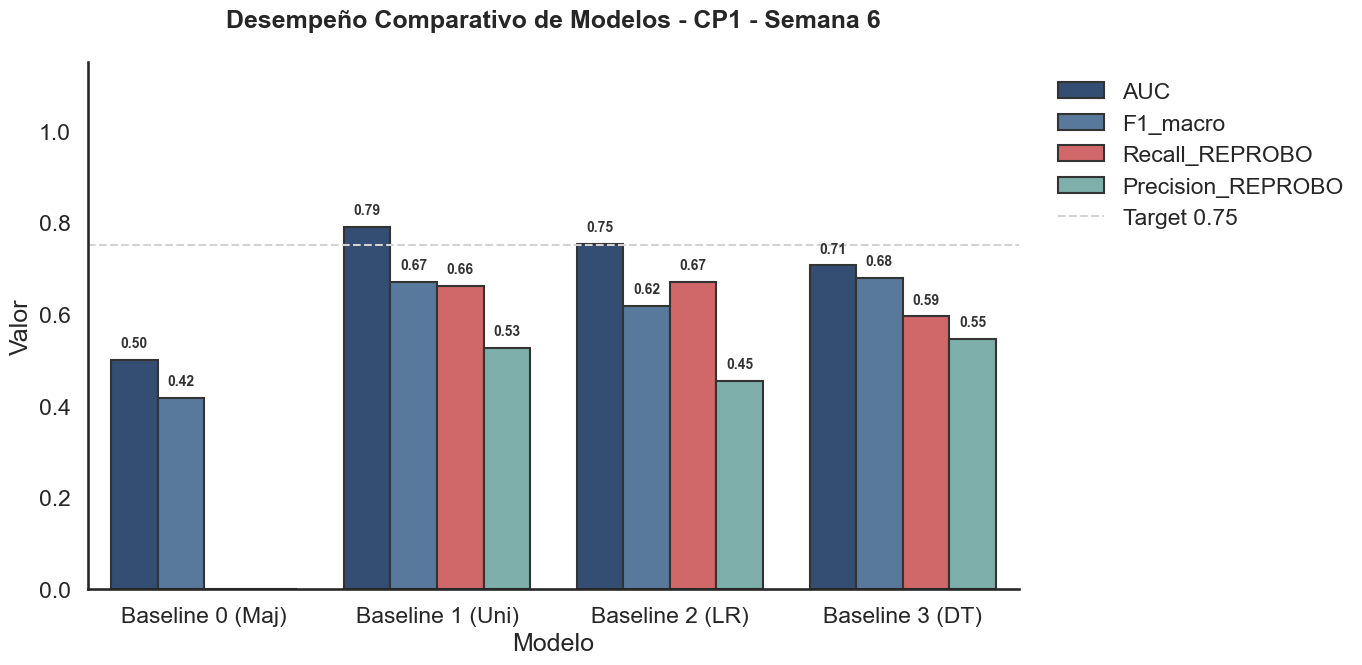

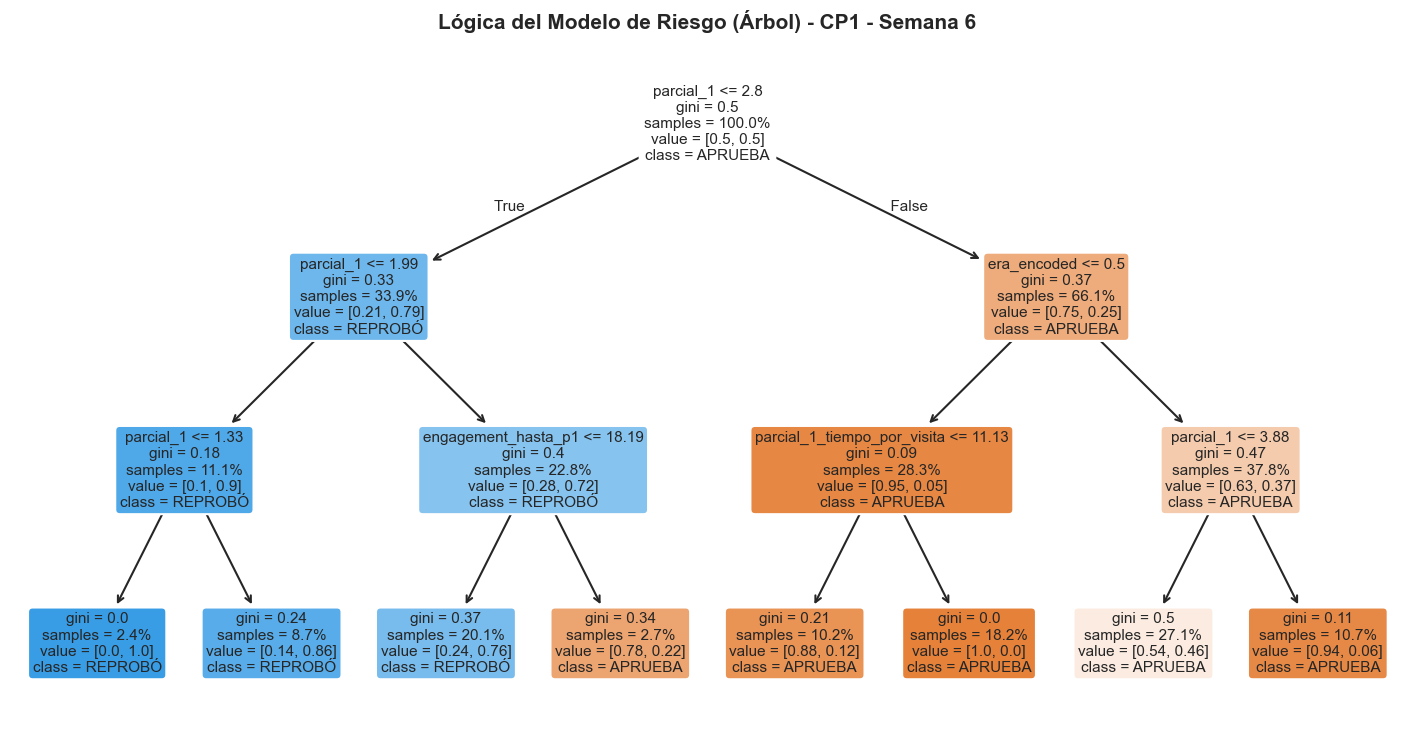


📊 Generando Reporte CP2...


c:\Users\nicot\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nicot\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nicot\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

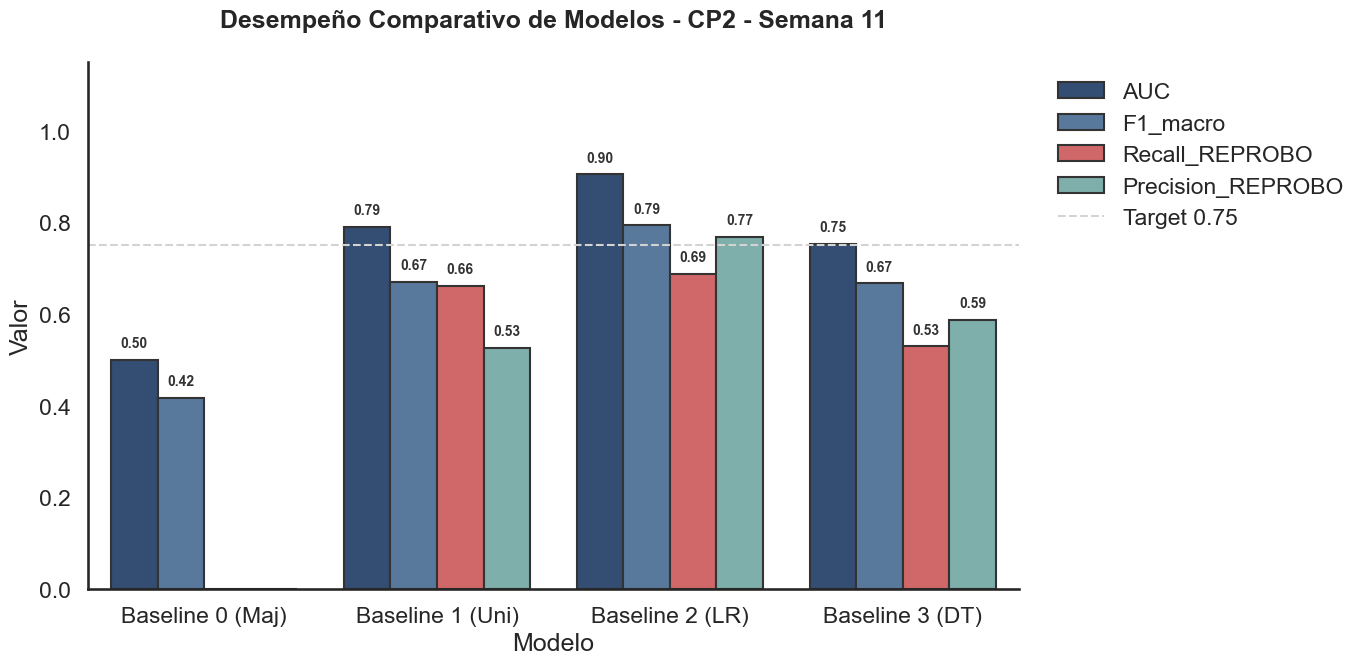

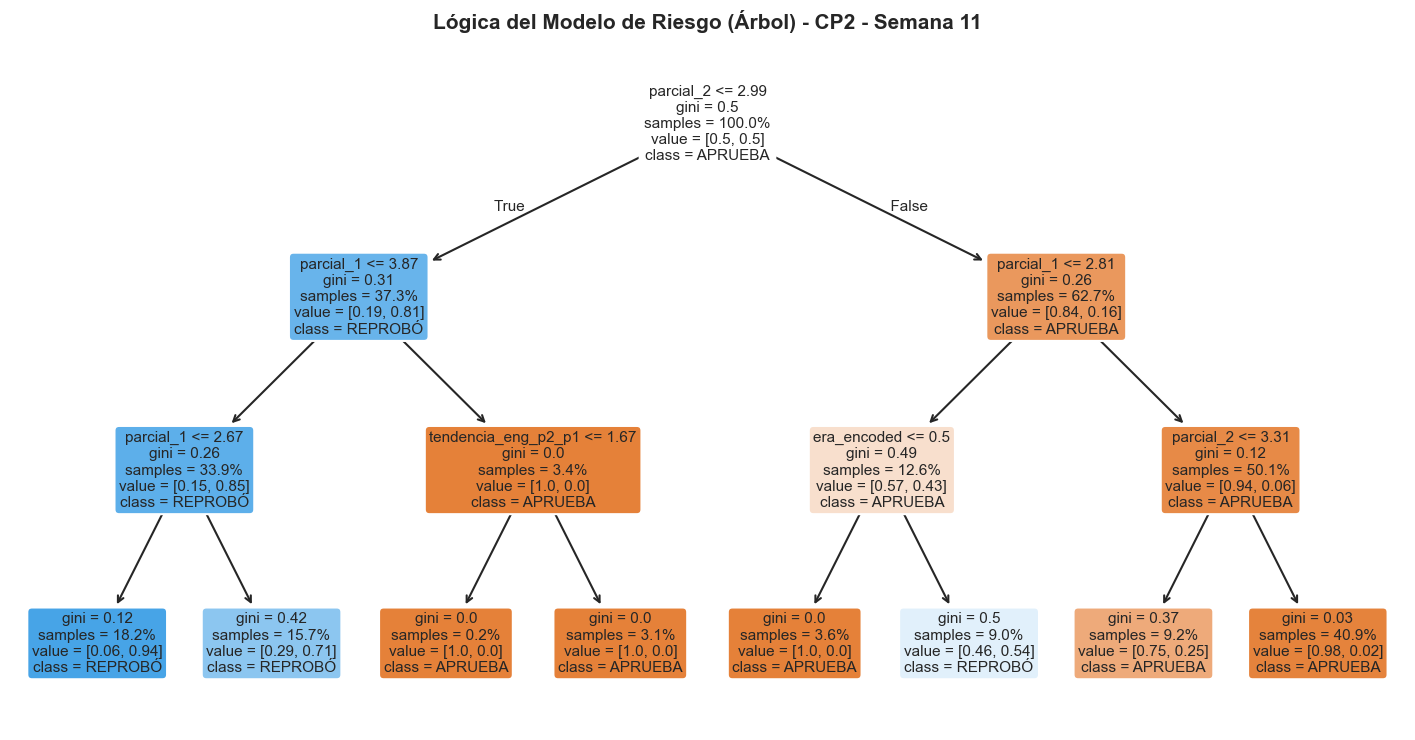

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, brier_score_loss

# 1. FUNCIÓN DE EVALUACIÓN
def evaluate_model(y_true, y_pred, proba):
    metrics = {
        'AUC': roc_auc_score(y_true, proba[:,1]),
        'F1_macro': f1_score(y_true, y_pred, average='macro'),
        'Recall_REPROBO': recall_score(y_true, y_pred),
        'Precision_REPROBO': precision_score(y_true, y_pred),
        'Brier': brier_score_loss(y_true, proba[:,1])
    }
    return metrics

# 2. FUNCIÓN DE VISUALIZACIÓN MEJORADA (Sin barras de error)
def plot_styled_results(df_res, cp_name):
    metric_cols = ['AUC', 'F1_macro', 'Recall_REPROBO', 'Precision_REPROBO']
    df_plot = df_res.melt(id_vars=['Modelo'], value_vars=metric_cols, var_name='Métrica', value_name='Valor')

    plt.figure(figsize=(14, 7))
    sns.set_style("white") 
    
    palette = {"AUC": "#2A4B7C", "F1_macro": "#4E79A7", "Recall_REPROBO": "#E15759", "Precision_REPROBO": "#76B7B2"}
    
    # AGREGADO: errorbar=None para quitar las líneas negras
    ax = sns.barplot(
        data=df_plot, 
        x='Modelo', 
        y='Valor', 
        hue='Métrica', 
        palette=palette, 
        edgecolor=".2",
        errorbar=None 
    )
    
    plt.title(f"Desempeño Comparativo de Modelos - {cp_name}", fontsize=18, fontweight='bold', pad=25)
    plt.axhline(0.75, color='#D3D3D3', linestyle='--', linewidth=1.5, label='Target 0.75')
    plt.ylim(0, 1.15) # Un poco más de margen arriba para las etiquetas
    
    # Etiquetas de datos con mejor visibilidad
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}', 
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', 
                        xytext=(0, 12), # Separación de la barra
                        textcoords='offset points', 
                        fontsize=10,
                        fontweight='bold',
                        color='#333333')

    sns.despine()
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()

# 3. FUNCIÓN DEL ÁRBOL
def plot_final_tree(dt, feature_names, cp_name):
    plt.figure(figsize=(18, 9))
    plot_tree(dt, 
              feature_names=list(feature_names), 
              class_names=['APRUEBA', 'REPROBÓ'], 
              filled=True, 
              rounded=True, 
              precision=2, 
              fontsize=11, 
              proportion=True)
    plt.title(f"Lógica del Modelo de Riesgo (Árbol) - {cp_name}", fontsize=15, fontweight='bold')
    plt.show()

# 4. FUNCIÓN RUN_BASELINES
def run_baselines(splits, cp_name="Punto de Control"):
    baseline_results = []
    last_run_data = {}

    for split_idx, (X_train, y_train, X_val, y_val, X_test, y_test) in enumerate(splits):
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        
        models = {
            'Baseline 0 (Maj)': (None, "const"),
            'Baseline 1 (Uni)': (Pipeline([('s', StandardScaler()), ('c', LogisticRegression(class_weight='balanced'))]), 'uni'),
            'Baseline 2 (LR)': (Pipeline([('s', StandardScaler()), ('c', LogisticRegression(class_weight='balanced', max_iter=1000))]), 'full'),
            'Baseline 3 (DT)': (DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42), 'full')
        }

        for name, (model, mode) in models.items():
            if mode == "const":
                y_pred = np.full(len(y_test), y_train.mode()[0])
                proba = np.zeros((len(y_test), 2))
                proba[:, y_train.mode()[0]] = 1
            else:
                f = ['parcial_1'] if mode == 'uni' else X_train.columns
                model.fit(X_train[f], y_train)
                y_pred = model.predict(X_test[f])
                proba = model.predict_proba(X_test[f])
            
            m = evaluate_model(y_test, y_pred, proba)
            baseline_results.append({'Split': split_idx, 'Modelo': name, **m})
            
            if name == 'Baseline 3 (DT)' and split_idx == len(splits)-1:
                last_run_data['dt'] = model
                last_run_data['feat'] = X_train.columns

    df_res = pd.DataFrame(baseline_results)
    
    plot_styled_results(df_res, cp_name)
    plot_final_tree(last_run_data['dt'], last_run_data['feat'], cp_name)

    return df_res.groupby('Modelo').mean(numeric_only=True)

# 5. EJECUCIÓN
print("📊 Generando Reporte CP1...")
res_cp1 = run_baselines(splits_cp1, cp_name="CP1 - Semana 6")

print("\n📊 Generando Reporte CP2...")
res_cp2 = run_baselines(splits_cp2, cp_name="CP2 - Semana 11")

In [27]:
def resumen_detallado_modelos(df_res, cp_name):
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE RESULTADOS: {cp_name}")
    print(f"{'='*70}\n")
    
    # Definiciones de los modelos para el reporte
    descripciones = {
        'Baseline 0 (Maj)': "Punto de comparación base. Predice que todos aprueban. Útil para medir el desbalance.",
        'Baseline 1 (Uni)': "Usa solo la nota del Parcial 1. Muestra qué tanto predice el pasado inmediato.",
        'Baseline 2 (LR)': "Regresión Logística con todas las variables. Busca relaciones lineales de riesgo.",
        'Baseline 3 (DT)': "Árbol de Decisión. Proporciona reglas claras (ej: 'Si falta a X, está en riesgo')."
    }

    for modelo in df_res.index:
        auc = df_res.loc[modelo, 'AUC']
        recall = df_res.loc[modelo, 'Recall_REPROBO']
        f1 = df_res.loc[modelo, 'F1_macro']
        
        # Lógica de interpretación
        if auc > 0.80: estatus = "⭐ EXCELENTE (Listo para intervención)"
        elif auc > 0.70: estatus = "✅ BUENO (Fiable para alertas)"
        else: estatus = "⚠️ LIMITADO (Requiere más variables)"

        print(f"MODELO: {modelo}")
        print(f"  └─ Propósito: {descripciones.get(modelo, 'Modelo personalizado')}")
        print(f"  └─ Desempeño: AUC: {auc:.3f} | F1: {f1:.3f} | Recall: {recall:.2f}")
        print(f"  └─ Diagnóstico: {estatus}")
        print("-" * 40)

# --- EJECUCIÓN DEL RESUMEN ---
resumen_detallado_modelos(res_cp1, "Punto de Control 1 (Semana 8)")
resumen_detallado_modelos(res_cp2, "Punto de Control 2 (Semana 12)")


ANÁLISIS DE RESULTADOS: Punto de Control 1 (Semana 8)

MODELO: Baseline 0 (Maj)
  └─ Propósito: Punto de comparación base. Predice que todos aprueban. Útil para medir el desbalance.
  └─ Desempeño: AUC: 0.500 | F1: 0.417 | Recall: 0.00
  └─ Diagnóstico: ⚠️ LIMITADO (Requiere más variables)
----------------------------------------
MODELO: Baseline 1 (Uni)
  └─ Propósito: Usa solo la nota del Parcial 1. Muestra qué tanto predice el pasado inmediato.
  └─ Desempeño: AUC: 0.791 | F1: 0.670 | Recall: 0.66
  └─ Diagnóstico: ✅ BUENO (Fiable para alertas)
----------------------------------------
MODELO: Baseline 2 (LR)
  └─ Propósito: Regresión Logística con todas las variables. Busca relaciones lineales de riesgo.
  └─ Desempeño: AUC: 0.753 | F1: 0.617 | Recall: 0.67
  └─ Diagnóstico: ✅ BUENO (Fiable para alertas)
----------------------------------------
MODELO: Baseline 3 (DT)
  └─ Propósito: Árbol de Decisión. Proporciona reglas claras (ej: 'Si falta a X, está en riesgo').
  └─ Desempeño: 

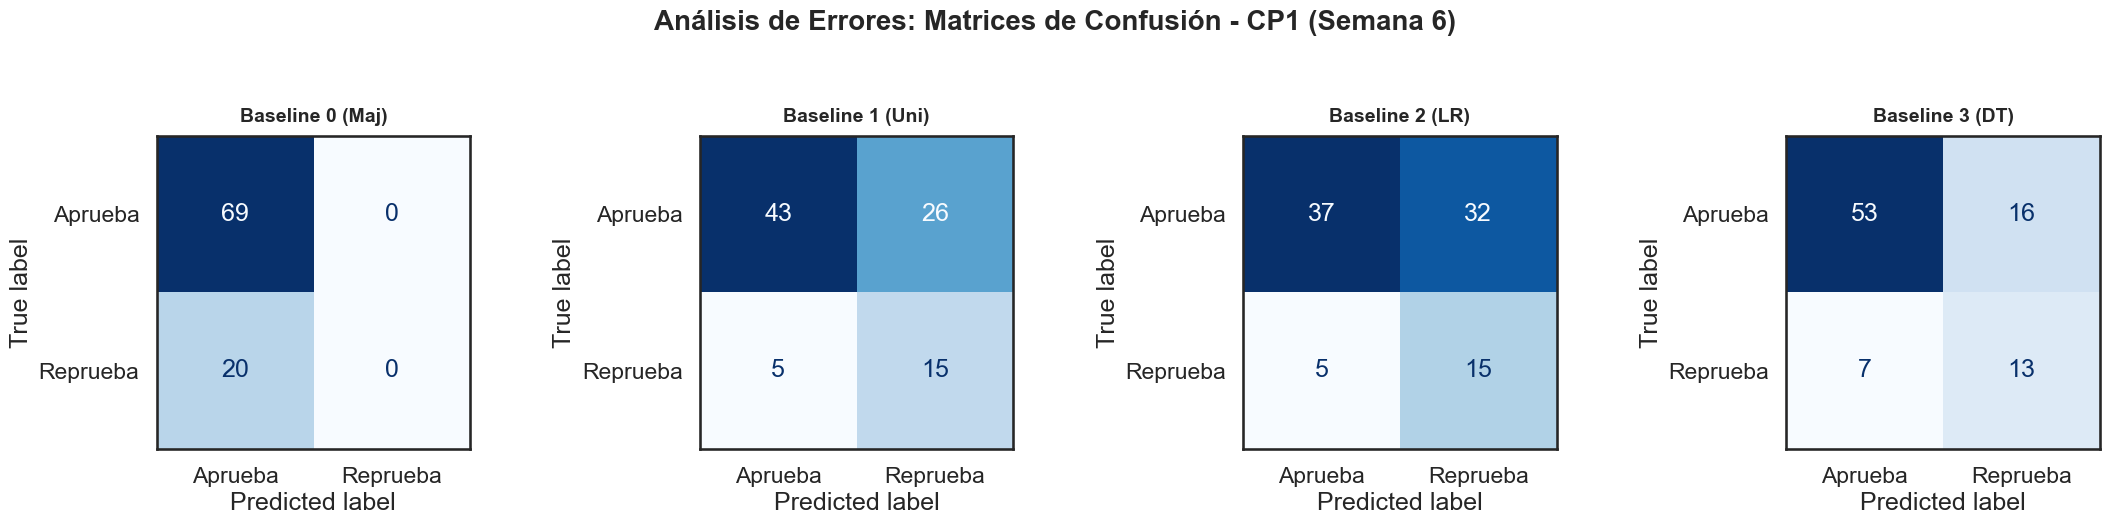

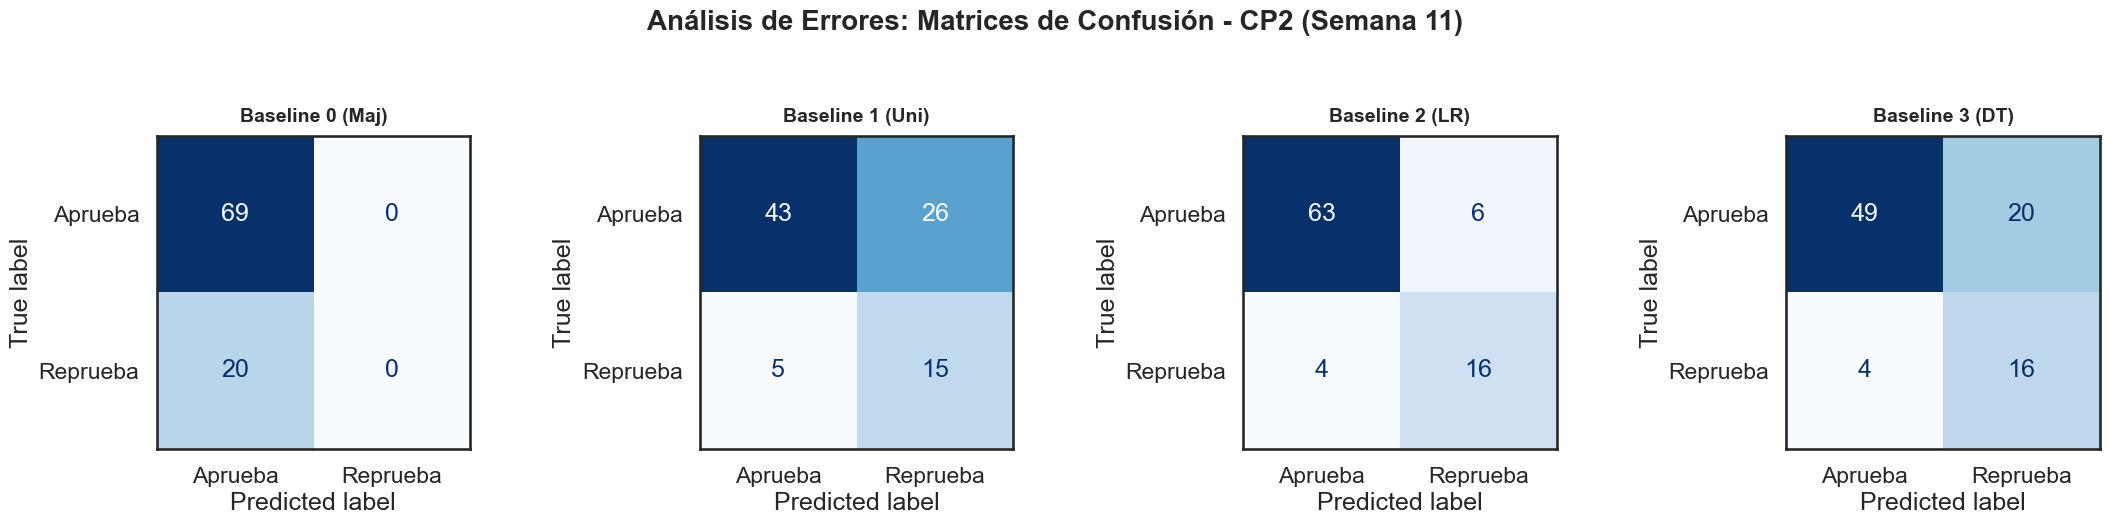

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix_dashboard(splits, cp_name="Punto de Control"):
    """
    Genera un tablero con las matrices de confusión de los 4 modelos
    comparándolos visualmente en un solo cuadro.
    """
    # Usamos el último split para la visualización (el más reciente/completo)
    X_train, y_train, X_val, y_val, X_test, y_test = splits[-1]
    X_test_aligned = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Definición de modelos para re-entrenar rápidamente el último split
    models = {
        'Baseline 0 (Maj)': None,
        'Baseline 1 (Uni)': Pipeline([('s', StandardScaler()), ('c', LogisticRegression(class_weight='balanced'))]),
        'Baseline 2 (LR)': Pipeline([('s', StandardScaler()), ('c', LogisticRegression(class_weight='balanced', max_iter=1000))]),
        'Baseline 3 (DT)': DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
    }

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f'Análisis de Errores: Matrices de Confusión - {cp_name}', fontsize=20, fontweight='bold', y=1.05)

    for i, (name, model) in enumerate(models.items()):
        if name == 'Baseline 0 (Maj)':
            y_pred = np.full(len(y_test), y_train.mode()[0])
        elif name == 'Baseline 1 (Uni)':
            f = ['parcial_1'] if 'parcial_1' in X_train.columns else [X_train.columns[0]]
            model.fit(X_train[f], y_train)
            y_pred = model.predict(X_test_aligned[f])
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test_aligned)

        cm = confusion_matrix(y_test, y_pred)
        
        # Estética de la matriz
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aprueba', 'Reprueba'])
        disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
        
        axes[i].set_title(name, fontsize=14, fontweight='bold', pad=10)
        axes[i].grid(False) # Quitar líneas de cuadrícula internas

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
plot_confusion_matrix_dashboard(splits_cp1, "CP1 (Semana 6)")
plot_confusion_matrix_dashboard(splits_cp2, "CP2 (Semana 11)")